# MODELO GRU:

In [ ]:
# Importar librerías para manipulación de datos
import pandas as pd  # Permite trabajar con tablas y estructuras tipo DataFrame

# Importar librería para operaciones numéricas
import numpy as np  # Permite trabajar con arrays y operaciones matemáticas

# Importar librería para visualización
import matplotlib.pyplot as plt  # Permite construir gráficos para analizar resultados

# Importar escalador robusto
from sklearn.preprocessing import RobustScaler  # Escala los datos reduciendo la influencia de valores atípicos

# Importar métricas de evaluación
from sklearn.metrics import mean_absolute_error, mean_squared_error  # Permite calcular MAE y RMSE

# Importar herramienta para generar combinaciones de hiperparámetros
from itertools import product  # Permite construir todas las combinaciones posibles de la grilla

# Importar módulo de aleatoriedad
import random  # Permite seleccionar combinaciones aleatorias de hiperparámetros

# Importar TensorFlow
import tensorflow as tf  # Framework principal para construir y entrenar redes neuronales

# Importar modelo secuencial de Keras
from tensorflow.keras.models import Sequential  # Permite construir modelos capa a capa

# Importar capas necesarias para el modelo GRU
from tensorflow.keras.layers import Input, GRU, Dense, Dropout  # Capas utilizadas en la arquitectura GRU

# Importar callback de parada temprana
from tensorflow.keras.callbacks import EarlyStopping  # Permite detener el entrenamiento cuando deja de mejorar

# Fijar semilla de NumPy
np.random.seed(42)  # Favorece la reproducibilidad de operaciones aleatorias en NumPy

# Fijar semilla del módulo random
random.seed(42)  # Favorece la reproducibilidad de la selección aleatoria de combinaciones

# Fijar semilla de TensorFlow
tf.random.set_seed(42)  # Favorece la reproducibilidad del entrenamiento en TensorFlow

# Configurar tamaño por defecto de las figuras
plt.rcParams["figure.figsize"] = (12, 5)  # Define un tamaño estándar para los gráficos

# Activar cuadrícula por defecto
plt.rcParams["axes.grid"] = True  # Facilita la lectura visual de los gráficos

In [ ]:
# Cargar el archivo CSV con la serie agregada de Galicia
df = pd.read_csv("bbdd_biogas_galicia.csv")  # Lee la base de datos desde el archivo CSV

# Convertir la columna datetime al formato de fecha
df["datetime"] = pd.to_datetime(df["datetime"])  # Asegura que la variable temporal tenga formato de fecha

# Ordenar las observaciones cronológicamente
df = df.sort_values("datetime")  # Garantiza que la serie respete el orden temporal

# Resetear el índice después de ordenar
df = df.reset_index(drop=True)  # Evita conservar el índice anterior tras la ordenación

# Seleccionar las columnas necesarias para el modelado
df_model = df[["datetime", "generacion_biogas_mwh"]].copy()  # Crea una copia con fecha y variable objetivo

# Extraer la serie objetivo como array
serie = df_model["generacion_biogas_mwh"].values  # Convierte la generación de biogás en un array de NumPy

# Mostrar el número total de observaciones
print("Número total de observaciones:", len(serie))  # Permite comprobar el tamaño de la serie

# Mostrar la fecha inicial
print("Fecha inicial:", df_model["datetime"].min())  # Muestra el inicio temporal de la serie

# Mostrar la fecha final
print("Fecha final:", df_model["datetime"].max())  # Muestra el final temporal de la serie

# Mostrar los primeros valores
print("\nPrimeros 5 valores de la serie:")  # Introduce la visualización inicial de valores

# Imprimir los primeros cinco valores
print(serie[:5])  # Permite comprobar que la serie se ha cargado correctamente

Número total de observaciones: 3638
Fecha inicial: 2016-04-06 00:00:00
Fecha final: 2026-03-22 00:00:00

Primeros 5 valores de la serie:
[ 78.426  78.66   84.376 100.137  84.765]


División cronológica en train, validation y test
**texto en negrita**
En esta celda se divide la serie en entrenamiento, validación y test, manteniendo estrictamente el orden temporal. Esta división es fundamental para que el modelo aprenda con información pasada y se evalúe sobre observaciones posteriores. Se conserva exactamente la misma proporción utilizada en los modelos anteriores para que la comparación entre RNN, LSTM y GRU sea consistente.

In [ ]:
# Definir proporción del conjunto de entrenamiento
train_ratio = 0.70  # El 70% inicial de la serie se usará para entrenamiento

# Definir proporción del conjunto de validación
val_ratio = 0.15  # El siguiente 15% se usará para validación

# Definir proporción del conjunto de test
test_ratio = 0.15  # El último 15% se reservará para evaluación final

# Calcular el número total de observaciones
n_total = len(serie)  # Obtiene la longitud completa de la serie

# Calcular el índice final del conjunto de entrenamiento
train_end = int(n_total * train_ratio)  # Marca el punto de corte entre train y validation

# Calcular el índice final del conjunto de validación
val_end = int(n_total * (train_ratio + val_ratio))  # Marca el punto de corte entre validation y test

# Crear conjunto de entrenamiento
train = serie[:train_end]  # Contiene las primeras observaciones de la serie

# Crear conjunto de validación
val = serie[train_end:val_end]  # Contiene el tramo posterior al entrenamiento

# Crear conjunto de test
test = serie[val_end:]  # Contiene el tramo final reservado para evaluación

# Mostrar tamaño del conjunto de entrenamiento
print("Tamaño train:", len(train))  # Comprueba el número de observaciones de train

# Mostrar tamaño del conjunto de validación
print("Tamaño validation:", len(val))  # Comprueba el número de observaciones de validation

# Mostrar tamaño del conjunto de test
print("Tamaño test:", len(test))  # Comprueba el número de observaciones de test

Tamaño train: 2546
Tamaño validation: 546
Tamaño test: 546


**Escalado robusto de la serie**

En este bloque se aplica RobustScaler, igual que en RNN y LSTM. El escalador se ajusta únicamente con el conjunto de entrenamiento y después se aplica a validación y test. Esta decisión evita fugas de información y mantiene el tratamiento de datos homogéneo entre arquitecturas.

In [ ]:
# Crear una instancia del escalador robusto
scaler = RobustScaler()  # Escalador basado en mediana y rango intercuartílico

# Ajustar el escalador con train y transformar train
train_scaled = scaler.fit_transform(train.reshape(-1, 1))  # Ajusta el escalador solo con entrenamiento

# Transformar validation usando el escalador ajustado en train
val_scaled = scaler.transform(val.reshape(-1, 1))  # Aplica el mismo escalado al conjunto de validación

# Transformar test usando el escalador ajustado en train
test_scaled = scaler.transform(test.reshape(-1, 1))  # Aplica el mismo escalado al conjunto de test

# Mostrar forma del conjunto de entrenamiento escalado
print("Forma train escalado:", train_scaled.shape)  # Comprueba la dimensión del array de train

# Mostrar forma del conjunto de validación escalado
print("Forma validation escalado:", val_scaled.shape)  # Comprueba la dimensión del array de validation

# Mostrar forma del conjunto de test escalado
print("Forma test escalado:", test_scaled.shape)  # Comprueba la dimensión del array de test

Forma train escalado: (2546, 1)
Forma validation escalado: (546, 1)
Forma test escalado: (546, 1)


**Creación de secuencias temporales**

En esta celda se define la función que transforma la serie temporal en un problema supervisado mediante ventanas deslizantes. Para cada ventana de observaciones pasadas, el objetivo será el valor inmediatamente posterior. Se reutiliza la misma función que en RNN y LSTM para mantener la coherencia entre modelos.

In [ ]:
# Definir función para crear secuencias temporales
def crear_secuencias(serie_escalada, window_size):  # Recibe una serie escalada y un tamaño de ventana

    # Crear lista vacía para entradas
    X = []  # Almacena las ventanas de observaciones pasadas

    # Crear lista vacía para salidas
    y = []  # Almacena el valor objetivo posterior a cada ventana

    # Recorrer la serie hasta el último punto posible
    for i in range(len(serie_escalada) - window_size):  # Evita crear ventanas incompletas

        # Guardar una ventana temporal como entrada
        X.append(serie_escalada[i:i + window_size])  # Contiene window_size observaciones pasadas

        # Guardar el valor inmediatamente posterior como salida
        y.append(serie_escalada[i + window_size])  # Contiene el valor a predecir

    # Convertir entradas a array de NumPy
    X = np.array(X)  # Convierte la lista de ventanas en array

    # Convertir salidas a array de NumPy
    y = np.array(y)  # Convierte la lista de objetivos en array

    # Devolver entradas y salidas
    return X, y  # Devuelve los datos listos para el modelado secuencial

**Definición de la grilla de hiperparámetros**

Aquí se define el espacio de búsqueda del modelo GRU. Se mantiene la misma grilla utilizada en RNN y LSTM: ventanas de 7, 14, 21 y 28 días, unidades recurrentes de 8, 16 y 32, tamaños de lote de 8, 16 y 32, y niveles de dropout de 0.0, 0.1 y 0.2. Esto permite que la comparación posterior entre arquitecturas sea metodológicamente justa.

In [ ]:
# Definir la grilla de hiperparámetros
param_grid = {  # Diccionario que contiene los valores posibles de cada hiperparámetro

    # Definir tamaños de ventana temporal
    "window_size": [7, 14, 21, 28],  # Ventanas basadas en la estructura semanal observada

    # Definir número de unidades recurrentes
    "units": [8, 16, 32],  # Número de neuronas en la capa GRU

    # Definir tamaños de lote
    "batch_size": [8, 16, 32],  # Número de muestras procesadas en cada actualización

    # Definir niveles de dropout
    "dropout": [0.0, 0.1, 0.2]  # Intensidad de regularización aplicada tras la capa GRU
}

# Construir todas las combinaciones posibles de la grilla
all_combinations = list(product(  # Genera el producto cartesiano de los hiperparámetros

    # Incluir posibles tamaños de ventana
    param_grid["window_size"],  # Valores posibles de window_size

    # Incluir posibles unidades GRU
    param_grid["units"],  # Valores posibles de units

    # Incluir posibles tamaños de batch
    param_grid["batch_size"],  # Valores posibles de batch_size

    # Incluir posibles valores de dropout
    param_grid["dropout"]  # Valores posibles de dropout
))

# Mostrar número total de combinaciones
print("Número total de combinaciones posibles:", len(all_combinations))  # Comprueba el tamaño de la grilla completa

Número total de combinaciones posibles: 108


**Selección aleatoria de combinaciones para Random Search**

En esta celda se selecciona una muestra aleatoria de combinaciones de hiperparámetros. Al igual que en RNN y LSTM, se prueban 20 combinaciones para equilibrar exploración del espacio de búsqueda y coste computacional. La selección es reproducible gracias a la semilla fijada previamente.

In [ ]:
# Definir número de combinaciones a evaluar
n_iter = 20  # Número de configuraciones que se probarán en el Random Search

# Asegurar que no se pidan más combinaciones de las disponibles
n_iter = min(n_iter, len(all_combinations))  # Evita errores si la grilla tuviera menos combinaciones

# Seleccionar combinaciones aleatorias sin reemplazo
sampled_combinations = random.sample(all_combinations, n_iter)  # Extrae una muestra aleatoria reproducible

# Mostrar número de combinaciones seleccionadas
print("Número de combinaciones seleccionadas:", len(sampled_combinations))  # Confirma cuántas configuraciones se evaluarán

# Mostrar las primeras combinaciones seleccionadas
print("\nPrimeras 5 combinaciones seleccionadas:")  # Introduce una comprobación rápida de la muestra

# Imprimir primeras cinco combinaciones
print(sampled_combinations[:5])  # Permite verificar los primeros valores seleccionados

Número de combinaciones seleccionadas: 20

Primeras 5 combinaciones seleccionadas:
[(28, 8, 8, 0.0), (7, 16, 16, 0.2), (7, 8, 16, 0.0), (28, 16, 16, 0.1), (14, 8, 32, 0.2)]


**Función para entrenar y evaluar una combinación GRU**

Este bloque define una función auxiliar que entrena y evalúa un modelo GRU para una combinación concreta de hiperparámetros. La función crea las secuencias, adapta su forma al formato requerido por Keras, construye el modelo, lo entrena con EarlyStopping y calcula las métricas de validación en MWh. Esta estructura replica la lógica de RNN y LSTM para que los resultados sean comparables.

In [ ]:
# Definir función para entrenar y evaluar una combinación concreta de hiperparámetros
def evaluar_gru(window_size, units, batch_size, dropout):  # Recibe los hiperparámetros de una configuración

    # Crear secuencias para entrenamiento
    X_train, y_train = crear_secuencias(train_scaled, window_size)  # Genera ventanas y objetivos de train

    # Crear secuencias para validación
    X_val, y_val = crear_secuencias(val_scaled, window_size)  # Genera ventanas y objetivos de validation

    # Reformatear X_train para Keras
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))  # Forma: muestras, pasos temporales, variables

    # Reformatear X_val para Keras
    X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))  # Mantiene la misma estructura tridimensional

    # Crear modelo secuencial vacío
    model = Sequential()  # Inicializa la arquitectura como una secuencia de capas

    # Añadir capa de entrada
    model.add(Input(shape=(window_size, 1)))  # Define la forma de entrada según la ventana temporal

    # Añadir capa GRU
    model.add(GRU(units=units))  # Capa recurrente GRU con el número de unidades indicado

    # Añadir capa de dropout
    model.add(Dropout(dropout))  # Aplica regularización después de la capa GRU

    # Añadir capa densa de salida
    model.add(Dense(1))  # Produce una única predicción numérica

    # Compilar el modelo
    model.compile(  # Define optimizador, pérdida y métrica de entrenamiento

        # Definir optimizador
        optimizer="adam",  # Optimizador usado también en RNN y LSTM

        # Definir función de pérdida
        loss=tf.keras.losses.Huber(),  # Pérdida robusta frente a errores extremos

        # Definir métrica adicional
        metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")]  # Registra MAE durante el entrenamiento
    )

    # Definir early stopping
    early_stopping = EarlyStopping(  # Callback para controlar el entrenamiento

        # Métrica monitorizada
        monitor="val_loss",  # Vigila la pérdida en validación

        # Número de épocas de paciencia
        patience=10,  # Espera 10 épocas sin mejora antes de detener

        # Restaurar mejores pesos
        restore_best_weights=True  # Recupera automáticamente la mejor versión del modelo
    )

    # Entrenar el modelo
    history = model.fit(  # Ajusta la red GRU a los datos de entrenamiento

        # Entradas de entrenamiento
        X_train,  # Secuencias de entrada de train

        # Objetivos de entrenamiento
        y_train,  # Valores objetivo de train

        # Datos de validación
        validation_data=(X_val, y_val),  # Evalúa el rendimiento en validation durante el entrenamiento

        # Número máximo de épocas
        epochs=100,  # Límite superior de épocas

        # Tamaño de batch
        batch_size=batch_size,  # Hiperparámetro evaluado en la búsqueda

        # Nivel de detalle de salida
        verbose=0,  # Oculta el progreso de cada época durante el Random Search

        # Callbacks utilizados
        callbacks=[early_stopping]  # Aplica parada temprana
    )

    # Generar predicciones escaladas en validación
    y_val_pred_scaled = model.predict(X_val, verbose=0)  # Predice sobre validation en escala transformada

    # Desescalar predicciones de validación
    y_val_pred = scaler.inverse_transform(y_val_pred_scaled)  # Convierte las predicciones a MWh

    # Desescalar valores reales de validación
    y_val_real = scaler.inverse_transform(y_val)  # Convierte los valores reales a MWh

    # Calcular MAE de validación
    mae_val = mean_absolute_error(y_val_real, y_val_pred)  # Calcula error absoluto medio en MWh

    # Calcular RMSE de validación
    rmse_val = np.sqrt(mean_squared_error(y_val_real, y_val_pred))  # Calcula raíz del error cuadrático medio en MWh

    # Obtener número de épocas entrenadas
    n_epochs = len(history.history["loss"])  # Cuenta cuántas épocas se ejecutaron realmente

    # Devolver resultados de la combinación
    return {  # Devuelve métricas, hiperparámetros y modelo entrenado

        # Guardar tamaño de ventana
        "window_size": window_size,  # Hiperparámetro window_size

        # Guardar unidades recurrentes
        "units": units,  # Hiperparámetro units

        # Guardar tamaño de batch
        "batch_size": batch_size,  # Hiperparámetro batch_size

        # Guardar dropout
        "dropout": dropout,  # Hiperparámetro dropout

        # Guardar épocas entrenadas
        "epochs_trained": n_epochs,  # Número efectivo de épocas

        # Guardar MAE de validación
        "val_mae": mae_val,  # Métrica principal de selección

        # Guardar RMSE de validación
        "val_rmse": rmse_val,  # Métrica complementaria

        # Guardar modelo entrenado
        "model": model  # Objeto del modelo entrenado
    }

**Ejecución del Random Search para GRU**

En esta celda se ejecuta la búsqueda aleatoria de hiperparámetros. Para cada combinación seleccionada, se entrena un modelo GRU y se guardan sus métricas de validación. Este bloque puede tardar varios minutos, pero es el paso que permite elegir la mejor configuración de forma objetiva.

In [ ]:
# Crear lista vacía para almacenar resultados
results = []  # Guardará los resultados de todas las combinaciones evaluadas

# Recorrer las combinaciones seleccionadas
for i, (window_size, units, batch_size, dropout) in enumerate(sampled_combinations, start=1):  # Itera sobre cada configuración

    # Mostrar progreso de la búsqueda
    print(f"Probando combinación {i}/{len(sampled_combinations)} -> window={window_size}, units={units}, batch={batch_size}, dropout={dropout}")  # Informa de la combinación actual

    # Evaluar combinación actual
    resultado = evaluar_gru(  # Entrena y evalúa un modelo GRU con la configuración actual

        # Pasar tamaño de ventana
        window_size=window_size,  # Define los días de entrada

        # Pasar número de unidades
        units=units,  # Define las unidades de la capa GRU

        # Pasar batch size
        batch_size=batch_size,  # Define el tamaño de lote

        # Pasar dropout
        dropout=dropout  # Define el nivel de regularización
    )

    # Guardar resultado obtenido
    results.append(resultado)  # Añade el diccionario de resultados a la lista

# Mostrar número total de resultados almacenados
print("\nNúmero total de resultados guardados:", len(results))  # Confirma que se evaluaron todas las combinaciones

Probando combinación 1/20 -> window=28, units=8, batch=8, dropout=0.0
Probando combinación 2/20 -> window=7, units=16, batch=16, dropout=0.2
Probando combinación 3/20 -> window=7, units=8, batch=16, dropout=0.0
Probando combinación 4/20 -> window=28, units=16, batch=16, dropout=0.1
Probando combinación 5/20 -> window=14, units=8, batch=32, dropout=0.2
Probando combinación 6/20 -> window=14, units=8, batch=16, dropout=0.1
Probando combinación 7/20 -> window=14, units=8, batch=8, dropout=0.1
Probando combinación 8/20 -> window=7, units=16, batch=32, dropout=0.2
Probando combinación 9/20 -> window=7, units=16, batch=16, dropout=0.1
Probando combinación 10/20 -> window=28, units=8, batch=16, dropout=0.2
Probando combinación 11/20 -> window=21, units=16, batch=32, dropout=0.0
Probando combinación 12/20 -> window=7, units=16, batch=8, dropout=0.2
Probando combinación 13/20 -> window=21, units=32, batch=16, dropout=0.0
Probando combinación 14/20 -> window=21, units=8, batch=8, dropout=0.0
Pro

**Tabla de resultados y selección del top 5**

Una vez finalizada la búsqueda, se transforman los resultados en un DataFrame y se ordenan por MAE de validación. Después se extraen las cinco mejores combinaciones, que servirán para justificar la selección de la configuración final del modelo GRU.

In [ ]:
# Convertir lista de resultados en DataFrame
results_df = pd.DataFrame(results)  # Cada fila representa una combinación evaluada

# Eliminar la columna del modelo para visualizar mejor la tabla
results_df_sin_modelo = results_df.drop(columns=["model"])  # Excluye el objeto modelo de la tabla

# Ordenar resultados por MAE de validación
results_df_sin_modelo = results_df_sin_modelo.sort_values(by="val_mae", ascending=True)  # Ordena de menor a mayor error

# Resetear índice de la tabla ordenada
results_df_sin_modelo = results_df_sin_modelo.reset_index(drop=True)  # Limpia el índice tras la ordenación

# Extraer las cinco mejores combinaciones
top5_gru = results_df_sin_modelo.head(5)  # Selecciona las cinco configuraciones con menor MAE

# Mostrar tabla top 5
print("Top 5 combinaciones de hiperparámetros para la GRU:\n")  # Título de salida

# Imprimir top 5
print(top5_gru)  # Muestra las cinco mejores configuraciones

Top 5 combinaciones de hiperparámetros para la GRU:

   window_size  units  batch_size  dropout  epochs_trained   val_mae  val_rmse
0           28      8           8      0.0              95  6.031956  7.784291
1           21     16          32      0.2              67  6.101506  7.965340
2           28     16          16      0.1              42  6.102071  7.821214
3           21     16          32      0.0              55  6.115496  7.872359
4           21      8           8      0.0              86  6.131229  7.877745


**Recuperación de la mejor combinación**

En esta celda se identifica la mejor combinación de hiperparámetros obtenida para el modelo GRU. Esta configuración se utilizará para reconstruir y entrenar el modelo final, igual que se hizo con RNN y LSTM.

In [ ]:
# Recuperar la mejor combinación de hiperparámetros
best_params = top5_gru.iloc[0]  # Selecciona la primera fila de la tabla ordenada

# Mostrar la mejor combinación encontrada
print("Mejor combinación encontrada para la GRU:\n")  # Título informativo

# Imprimir mejores parámetros
print(best_params)  # Muestra los hiperparámetros y métricas de la mejor configuración

# Extraer mejor tamaño de ventana
best_window = int(best_params["window_size"])  # Convierte el valor de ventana a entero

# Extraer mejor número de unidades
best_units = int(best_params["units"])  # Convierte el número de unidades a entero

# Extraer mejor batch size
best_batch = int(best_params["batch_size"])  # Convierte el batch size a entero

# Extraer mejor dropout
best_dropout = float(best_params["dropout"])  # Convierte el dropout a decimal

Mejor combinación encontrada para la GRU:

window_size       28.000000
units              8.000000
batch_size         8.000000
dropout            0.000000
epochs_trained    95.000000
val_mae            6.031956
val_rmse           7.784291
Name: 0, dtype: float64


**Preparación de secuencias con la mejor ventana**

Aquí se reconstruyen las secuencias de entrenamiento, validación y test utilizando la mejor ventana encontrada. Posteriormente, se reformatean los datos a la estructura tridimensional requerida por Keras. Este bloque deja preparados los datos para entrenar el modelo GRU final.

In [ ]:
# Crear secuencias de entrenamiento con la mejor ventana
X_train_best, y_train_best = crear_secuencias(train_scaled, best_window)  # Genera X e y de train

# Crear secuencias de validación con la mejor ventana
X_val_best, y_val_best = crear_secuencias(val_scaled, best_window)  # Genera X e y de validation

# Crear secuencias de test con la mejor ventana
X_test_best, y_test_best = crear_secuencias(test_scaled, best_window)  # Genera X e y de test

# Reformatear X_train para Keras
X_train_best = X_train_best.reshape((X_train_best.shape[0], X_train_best.shape[1], 1))  # Convierte train a formato 3D

# Reformatear X_val para Keras
X_val_best = X_val_best.reshape((X_val_best.shape[0], X_val_best.shape[1], 1))  # Convierte validation a formato 3D

# Reformatear X_test para Keras
X_test_best = X_test_best.reshape((X_test_best.shape[0], X_test_best.shape[1], 1))  # Convierte test a formato 3D

# Mostrar forma final de train
print("X_train_best:", X_train_best.shape, "y_train_best:", y_train_best.shape)  # Comprueba dimensiones de train

# Mostrar forma final de validation
print("X_val_best:", X_val_best.shape, "y_val_best:", y_val_best.shape)  # Comprueba dimensiones de validation

# Mostrar forma final de test
print("X_test_best:", X_test_best.shape, "y_test_best:", y_test_best.shape)  # Comprueba dimensiones de test

X_train_best: (2518, 28, 1) y_train_best: (2518, 1)
X_val_best: (518, 28, 1) y_val_best: (518, 1)
X_test_best: (518, 28, 1) y_test_best: (518, 1)


**Construcción y entrenamiento del modelo GRU final**

En este bloque se construye el modelo GRU final utilizando la mejor combinación de hiperparámetros obtenida en el Random Search. La arquitectura se mantiene sencilla y comparable con RNN y LSTM: una capa de entrada, una capa GRU, una capa de dropout y una capa densa de salida. El entrenamiento se realiza con EarlyStopping.

In [ ]:
# Crear modelo GRU final
modelo_gru_final = Sequential()  # Inicializa un modelo secuencial vacío

# Añadir capa de entrada
modelo_gru_final.add(Input(shape=(best_window, 1)))  # Define la forma de entrada según la mejor ventana

# Añadir capa GRU
modelo_gru_final.add(GRU(units=best_units))  # Capa GRU con el mejor número de unidades encontrado

# Añadir capa de dropout
modelo_gru_final.add(Dropout(best_dropout))  # Aplica el mejor nivel de dropout encontrado

# Añadir capa densa de salida
modelo_gru_final.add(Dense(1))  # Devuelve una única predicción de generación

# Compilar modelo final
modelo_gru_final.compile(  # Define configuración de aprendizaje del modelo

    # Definir optimizador
    optimizer="adam",  # Mantiene el mismo optimizador que en RNN y LSTM

    # Definir función de pérdida
    loss=tf.keras.losses.Huber(),  # Mantiene la misma función de pérdida robusta

    # Definir métrica de entrenamiento
    metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")]  # Registra el MAE durante el entrenamiento
)

# Definir early stopping para el modelo final
early_stopping_final = EarlyStopping(  # Callback de parada temprana

    # Definir métrica monitorizada
    monitor="val_loss",  # Observa la pérdida de validación

    # Definir paciencia
    patience=10,  # Detiene el entrenamiento tras 10 épocas sin mejora

    # Restaurar mejores pesos
    restore_best_weights=True  # Recupera la mejor versión del modelo entrenado
)

# Entrenar el modelo GRU final
history_gru_final = modelo_gru_final.fit(  # Ajusta el modelo final a los datos

    # Entradas de entrenamiento
    X_train_best,  # Secuencias de entrenamiento

    # Objetivos de entrenamiento
    y_train_best,  # Valores objetivo de entrenamiento

    # Datos de validación
    validation_data=(X_val_best, y_val_best),  # Evalúa el modelo durante el entrenamiento

    # Número máximo de épocas
    epochs=100,  # Límite máximo de entrenamiento

    # Mejor tamaño de batch
    batch_size=best_batch,  # Usa el batch size seleccionado

    # Mostrar progreso
    verbose=1,  # Muestra el progreso de cada época

    # Aplicar early stopping
    callbacks=[early_stopping_final]  # Incorpora parada temprana
)

Epoch 1/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.4800 - mae: 0.7967 - val_loss: 0.1817 - val_mae: 0.5033
Epoch 2/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.4186 - mae: 0.7127 - val_loss: 0.1359 - val_mae: 0.4264
Epoch 3/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.3995 - mae: 0.6787 - val_loss: 0.1269 - val_mae: 0.4086
Epoch 4/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.3934 - mae: 0.6676 - val_loss: 0.1233 - val_mae: 0.4013
Epoch 5/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.3882 - mae: 0.6590 - val_loss: 0.1201 - val_mae: 0.3952
Epoch 6/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.3834 - mae: 0.6513 - val_loss: 0.1165 - val_mae: 0.3887
Epoch 7/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.3785 - mae: 0.6438 - val_loss: 0.1122 - val_mae: 0.3811
Epoch 8/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.3732 - mae: 0.6352 - val_loss: 0.1072 - val_mae: 0.3719
Epoch 9/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/

**Evolución de la pérdida del modelo GRU**

Esta celda representa la evolución de la pérdida durante el entrenamiento del modelo final. El objetivo es comprobar visualmente la estabilidad del entrenamiento y disponer de una figura equivalente a las utilizadas en RNN y LSTM para la posterior redacción de resultados.

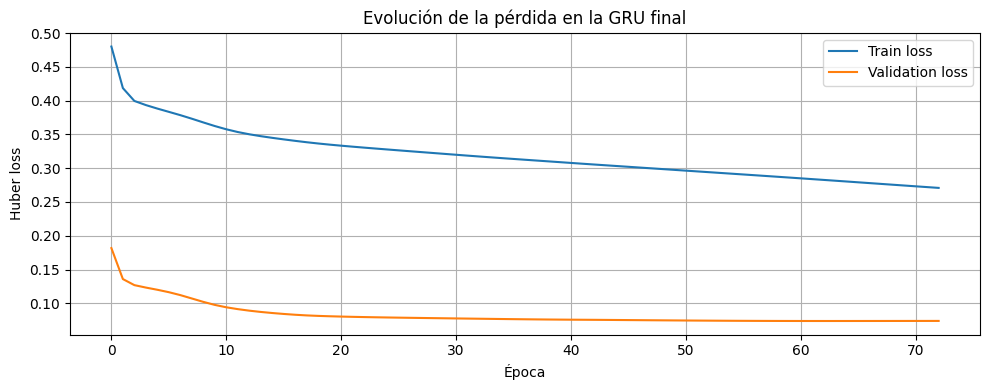

In [ ]:
# Crear figura para la evolución de la pérdida
plt.figure(figsize=(10, 4))  # Define el tamaño de la figura

# Representar pérdida de entrenamiento
plt.plot(history_gru_final.history["loss"], label="Train loss")  # Dibuja la curva de pérdida en entrenamiento

# Representar pérdida de validación
plt.plot(history_gru_final.history["val_loss"], label="Validation loss")  # Dibuja la curva de pérdida en validación

# Añadir título
plt.title("Evolución de la pérdida en la GRU final")  # Define el título del gráfico

# Añadir etiqueta del eje X
plt.xlabel("Época")  # Indica las épocas en el eje horizontal

# Añadir etiqueta del eje Y
plt.ylabel("Huber loss")  # Indica la pérdida Huber en el eje vertical

# Añadir leyenda
plt.legend()  # Muestra la identificación de las curvas

# Ajustar diseño
plt.tight_layout()  # Mejora la distribución visual del gráfico

# Mostrar figura
plt.show()  # Renderiza el gráfico

**Predicciones en validation y test**
En este bloque se generan las predicciones del modelo GRU final sobre validación y test. Después se invierte el escalado para expresar tanto los valores reales como las predicciones en MWh. Esto permite calcular métricas comparables con RNN, LSTM y los modelos baseline.

In [ ]:
# Generar predicciones escaladas sobre validation
y_val_pred_scaled = modelo_gru_final.predict(X_val_best, verbose=0)  # Predice validation en escala transformada

# Generar predicciones escaladas sobre test
y_test_pred_scaled = modelo_gru_final.predict(X_test_best, verbose=0)  # Predice test en escala transformada

# Desescalar predicciones de validation
y_val_pred = scaler.inverse_transform(y_val_pred_scaled)  # Convierte predicciones de validation a MWh

# Desescalar predicciones de test
y_test_pred = scaler.inverse_transform(y_test_pred_scaled)  # Convierte predicciones de test a MWh

# Desescalar valores reales de validation
y_val_real = scaler.inverse_transform(y_val_best)  # Convierte valores reales de validation a MWh

# Desescalar valores reales de test
y_test_real = scaler.inverse_transform(y_test_best)  # Convierte valores reales de test a MWh

**Cálculo de métricas finales**

Aquí se calculan las métricas finales del modelo GRU sobre validación y test. Se mantiene el mismo conjunto de métricas empleado en RNN y LSTM: MAE y RMSE en MWh. Estos valores serán los que después utilizarás para redactar la subsección de resultados de GRU y para construir la tabla comparativa final de modelos.

In [ ]:
# Calcular MAE en validation
mae_val_final = mean_absolute_error(y_val_real, y_val_pred)  # Error absoluto medio en validation

# Calcular RMSE en validation
rmse_val_final = np.sqrt(mean_squared_error(y_val_real, y_val_pred))  # Raíz del error cuadrático medio en validation

# Calcular MAE en test
mae_test_final = mean_absolute_error(y_test_real, y_test_pred)  # Error absoluto medio en test

# Calcular RMSE en test
rmse_test_final = np.sqrt(mean_squared_error(y_test_real, y_test_pred))  # Raíz del error cuadrático medio en test

# Mostrar título de resultados
print("Resultados finales del modelo GRU")  # Identifica el bloque de salida

# Mostrar MAE de validation
print(f"MAE validation:  {mae_val_final:.3f} MWh")  # Imprime MAE de validación en MWh

# Mostrar RMSE de validation
print(f"RMSE validation: {rmse_val_final:.3f} MWh")  # Imprime RMSE de validación en MWh

# Mostrar MAE de test
print(f"MAE test:        {mae_test_final:.3f} MWh")  # Imprime MAE de test en MWh

# Mostrar RMSE de test
print(f"RMSE test:       {rmse_test_final:.3f} MWh")  # Imprime RMSE de test en MWh

Resultados finales del modelo GRU
MAE validation:  6.105 MWh
RMSE validation: 7.802 MWh
MAE test:        5.750 MWh
RMSE test:       7.448 MWh


**Comparación gráfica entre valores reales y predichos en test**

Esta celda representa una parte del conjunto de test comparando valores reales y predichos. Se mantiene el mismo formato visual que en RNN y LSTM para facilitar la comparación cualitativa entre arquitecturas.

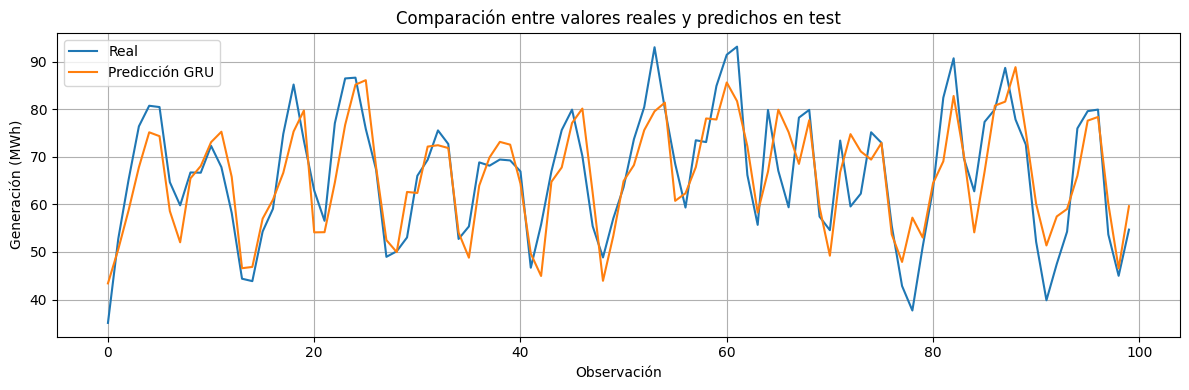

In [ ]:
# Definir número de observaciones a mostrar
n_mostrar = 100  # Número de puntos del test que se representarán

# Crear figura
plt.figure(figsize=(12, 4))  # Define tamaño del gráfico

# Representar valores reales del test
plt.plot(y_test_real[:n_mostrar], label="Real")  # Dibuja la serie observada

# Representar predicciones del test
plt.plot(y_test_pred[:n_mostrar], label="Predicción GRU")  # Dibuja la serie predicha por GRU

# Añadir título
plt.title("Comparación entre valores reales y predichos en test")  # Título del gráfico

# Añadir etiqueta del eje X
plt.xlabel("Observación")  # Identifica las observaciones del test

# Añadir etiqueta del eje Y
plt.ylabel("Generación (MWh)")  # Identifica la unidad de generación

# Añadir leyenda
plt.legend()  # Muestra etiquetas de las series

# Ajustar diseño
plt.tight_layout()  # Mejora el ajuste de la figura

# Mostrar gráfico
plt.show()  # Renderiza el gráfico

**Tabla resumen del top 5 de hiperparámetros**

Este bloque genera una tabla limpia con las cinco mejores combinaciones de hiperparámetros de la GRU. Esta salida es útil para documentar la selección del modelo y justificar la configuración final utilizada.

In [ ]:
# Crear copia de la tabla top 5
tabla_top5_gru = top5_gru.copy()  # Copia independiente para formatear resultados

# Redondear MAE de validación
tabla_top5_gru["val_mae"] = tabla_top5_gru["val_mae"].round(3)  # Redondea MAE a tres decimales

# Redondear RMSE de validación
tabla_top5_gru["val_rmse"] = tabla_top5_gru["val_rmse"].round(3)  # Redondea RMSE a tres decimales

# Renombrar columnas
tabla_top5_gru = tabla_top5_gru.rename(columns={  # Cambia nombres para presentación

    # Renombrar tamaño de ventana
    "window_size": "Window size",  # Nombre más legible para window_size

    # Renombrar unidades
    "units": "Units",  # Nombre más legible para units

    # Renombrar batch size
    "batch_size": "Batch size",  # Nombre más legible para batch_size

    # Renombrar dropout
    "dropout": "Dropout",  # Nombre más legible para dropout

    # Renombrar épocas entrenadas
    "epochs_trained": "Epochs trained",  # Nombre más legible para epochs_trained

    # Renombrar MAE de validación
    "val_mae": "Validation MAE",  # Nombre más claro para MAE

    # Renombrar RMSE de validación
    "val_rmse": "Validation RMSE"  # Nombre más claro para RMSE
})

# Mostrar título de la tabla
print("Tabla resumen con las 5 mejores combinaciones de hiperparámetros para la GRU:\n")  # Identifica la tabla

# Mostrar tabla
print(tabla_top5_gru)  # Imprime la tabla formateada

# Mostrar tabla con formato enriquecido en Colab
tabla_top5_gru  # Permite visualizar la tabla como DataFrame

Tabla resumen con las 5 mejores combinaciones de hiperparámetros para la GRU:

   Window size  Units  Batch size  Dropout  Epochs trained  Validation MAE  \
0           28      8           8      0.0              95           6.032   
1           21     16          32      0.2              67           6.102   
2           28     16          16      0.1              42           6.102   
3           21     16          32      0.0              55           6.115   
4           21      8           8      0.0              86           6.131   

   Validation RMSE  
0            7.784  
1            7.965  
2            7.821  
3            7.872  
4            7.878  


,Window size,Units,Batch size,Dropout,Epochs trained,Validation MAE,Validation RMSE
0,28,8,8,0.0,95,6.032,7.784
1,21,16,32,0.2,67,6.102,7.965
2,28,16,16,0.1,42,6.102,7.821
3,21,16,32,0.0,55,6.115,7.872
4,21,8,8,0.0,86,6.131,7.878


**Gráfico final amplio de predicciones en train y test**

Este último bloque genera una visualización amplia de los valores reales y predichos en entrenamiento y test. Su utilidad es principalmente visual y comparativa, especialmente si quieres mantener el mismo tipo de gráfico final que en RNN y LSTM.

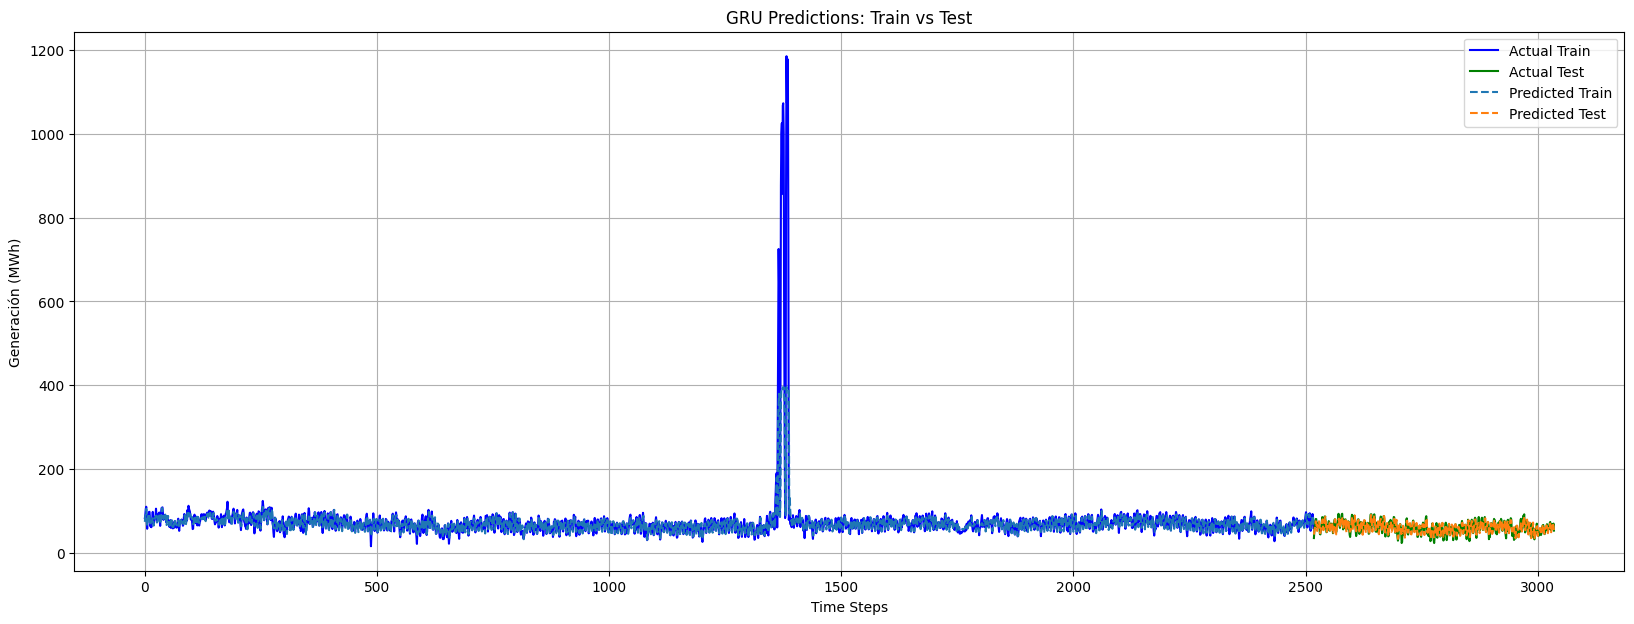

In [ ]:
# Generar predicciones escaladas sobre train
y_train_pred_scaled = modelo_gru_final.predict(X_train_best, verbose=0)  # Predice train en escala transformada

# Generar predicciones escaladas sobre test
y_test_pred_scaled = modelo_gru_final.predict(X_test_best, verbose=0)  # Predice test en escala transformada

# Desescalar predicciones de train
y_train_pred = scaler.inverse_transform(y_train_pred_scaled)  # Convierte predicciones de train a MWh

# Desescalar predicciones de test
y_test_pred = scaler.inverse_transform(y_test_pred_scaled)  # Convierte predicciones de test a MWh

# Desescalar valores reales de train
y_train_real = scaler.inverse_transform(y_train_best)  # Convierte valores reales de train a MWh

# Desescalar valores reales de test
y_test_real = scaler.inverse_transform(y_test_best)  # Convierte valores reales de test a MWh

# Crear eje temporal para train
train_time_steps = range(len(y_train_real))  # Índices temporales del tramo de entrenamiento

# Crear eje temporal para test
test_time_steps = range(len(y_train_real), len(y_train_real) + len(y_test_real))  # Índices temporales del tramo de test

# Crear figura grande
plt.figure(figsize=(20, 7))  # Define un tamaño amplio para visualizar toda la serie

# Representar valores reales de train
plt.plot(train_time_steps, y_train_real, label="Actual Train", color="blue")  # Dibuja la serie real de entrenamiento

# Representar valores reales de test
plt.plot(test_time_steps, y_test_real, label="Actual Test", color="green")  # Dibuja la serie real de test

# Representar predicción de train
plt.plot(train_time_steps, y_train_pred, label="Predicted Train", linestyle="--")  # Dibuja predicción de entrenamiento

# Representar predicción de test
plt.plot(test_time_steps, y_test_pred, label="Predicted Test", linestyle="--")  # Dibuja predicción de test

# Añadir título
plt.title("GRU Predictions: Train vs Test")  # Título del gráfico

# Añadir etiqueta eje X
plt.xlabel("Time Steps")  # Etiqueta del eje horizontal

# Añadir etiqueta eje Y
plt.ylabel("Generación (MWh)")  # Etiqueta del eje vertical

# Añadir leyenda
plt.legend()  # Muestra etiquetas de cada serie

# Activar cuadrícula
plt.grid(True)  # Mejora la lectura visual

# Mostrar gráfico
plt.show()  # Renderiza la figura

**Evolución del MAE en entrenamiento y validación**

Para completar el análisis del entrenamiento del modelo GRU final se representa la evolución del MAE a lo largo de las épocas, comparando el comportamiento del modelo en el conjunto de entrenamiento y en el de validación. A diferencia de la curva de pérdida Huber mostrada anteriormente, aquí el error se expresa directamente en MWh, lo que facilita su interpretación en el dominio de la generación eléctrica. Esta visualización permite valorar la velocidad de convergencia, la estabilidad del entrenamiento y la posible aparición de sobreajuste a través de la separación entre ambas curvas.

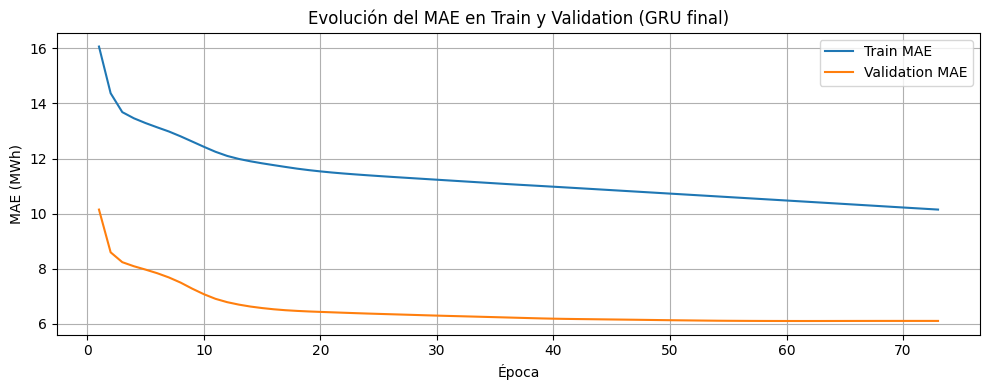

In [ ]:
# Recuperar el factor de escala del RobustScaler para expresar el MAE en MWh
iqr_factor = scaler.scale_[0]                                             # Factor de escala (IQR) usado por RobustScaler

# Convertir el MAE de train por época a la escala original (MWh)
train_mae_mwh = [m * iqr_factor for m in history_gru_final.history["mae"]]      # MAE de train por época en MWh

# Convertir el MAE de validation por época a la escala original (MWh)
val_mae_mwh = [m * iqr_factor for m in history_gru_final.history["val_mae"]]    # MAE de validación por época en MWh

# Construir un eje de épocas común
epochs_axis = range(1, len(train_mae_mwh) + 1)                            # Eje de épocas comenzando en 1

# Crear figura
plt.figure(figsize=(10, 4))                                               # Tamaño de la figura

# Representar la curva de MAE en entrenamiento
plt.plot(epochs_axis, train_mae_mwh, label="Train MAE")                   # Curva de MAE de train en MWh

# Representar la curva de MAE en validación
plt.plot(epochs_axis, val_mae_mwh, label="Validation MAE")                # Curva de MAE de validación en MWh

# Añadir título y etiquetas
plt.title("Evolución del MAE en Train y Validation (GRU final)")          # Título del gráfico
plt.xlabel("Época")                                                       # Etiqueta del eje X
plt.ylabel("MAE (MWh)")                                                   # Etiqueta del eje Y

# Añadir leyenda y ajustar diseño
plt.legend()                                                              # Mostrar leyenda
plt.tight_layout()                                                        # Ajustar márgenes automáticamente

# Mostrar figura
plt.show()                                                                # Renderizar gráfico

In [ ]:
# Calcular MAE en train
mae_train_final = mean_absolute_error(y_train_real, y_train_pred)  # Error absoluto medio en train

# Calcular RMSE en train
rmse_train_final = np.sqrt(mean_squared_error(y_train_real, y_train_pred))  # Raíz del error cuadrático medio en train

# Mostrar título de resultados
print("Métricas del modelo GRU en train")

# Mostrar MAE de train
print(f"MAE train:  {mae_train_final:.3f} MWh")

# Mostrar RMSE de train
print(f"RMSE train: {rmse_train_final:.3f} MWh")

Métricas del modelo GRU en train
MAE train:  10.304 MWh
RMSE train: 49.206 MWh
